In [1]:
# Below snippet of codes have been copied and learnt from Alexander's notebook. https://www.kaggle.com/alexryzhkov (Checkout his notebooks on LAMA)

from IPython.core.display import display, HTML, Javascript

# ----- Notebook Theme -----
color_map = ['#F05454', '#f6ebe8', '#ecd7d0', '#d9c1a2', '#d9afa2', '#b35b45', 
                        '#F05454', '#8d2713', '#7a2b11', '#7a2611', '#53190b']

prompt = color_map[-1]
main_color = color_map[0]
strong_main_color = color_map[1]
custom_colors = [strong_main_color, main_color]

css_file = ''' 

div #notebook {
background-color: white;
line-height: 20px;
}

#notebook-container {
%s
margin-top: 2em;
padding-top: 2em;
border-top: 4px solid %s; /* light orange */
-webkit-box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5); /* pink */
    box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5); /* pink */
}

div .input {
margin-bottom: 1em;
}

.rendered_html h1, .rendered_html h2, .rendered_html h3, .rendered_html h4, .rendered_html h5, .rendered_html h6 {
color: %s; /* light orange */
font-weight: 600;
}

div.input_area {
border: none;
    background-color: %s; /* rgba(229, 143, 101, 0.1); light orange [exactly #E58F65] */
    border-top: 2px solid %s; /* light orange */
}

div.input_prompt {
color: %s; /* light blue */
}

div.output_prompt {
color: %s; /* strong orange */
}

div.cell.selected:before, div.cell.selected.jupyter-soft-selected:before {
background: %s; /* light orange */
}

div.cell.selected, div.cell.selected.jupyter-soft-selected {
    border-color: %s; /* light orange */
}

.edit_mode div.cell.selected:before {
background: %s; /* light orange */
}

.edit_mode div.cell.selected {
border-color: %s; /* light orange */

}
'''
def to_rgb(h): 
    return tuple(int(h[i:i+2], 16) for i in [0, 2, 4])

main_color_rgba = 'rgba(%s, %s, %s, 0.1)' % (to_rgb(main_color[1:]))
open('notebook.css', 'w').write(css_file % ('width: 95%;', main_color, main_color, main_color_rgba, main_color,  main_color, prompt, main_color, main_color, main_color, main_color))

def nb(): 
    return HTML("<style>" + open("notebook.css", "r").read() + "</style>")
nb()

<h1 style="font-size:80px;color:#F05454;text-align:center"><strong>A Guide</strong> <strong style="color:black">To Understand Visualizations</strong></h1>

In [2]:
# For the purpose of this tutorial, I am going to make use of Matplotlib and Seaborn only.
import numpy as np 
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') # This will just style our plots (you can explore more plots here: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html)
import seaborn as sns
import squarify

# To store the visualizations in the notebook (you can read more about it here: https://stackoverflow.com/questions/43027980/purpose-of-matplotlib-inline)
%matplotlib inline


# This part of the code is just to supress any unwanted warnings that may appear
import warnings
warnings.filterwarnings('ignore')

In [3]:
'''For this tutorial, I will be using the "Superstore" Dataset from "https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls"
(I have modified this file and saved this into a csv format; You can find this dataset in my profile)'''

df = pd.read_csv('../input/superstore-dataset-final/Sample - Superstore.csv', encoding='windows-1252') # This line will read the csv file

# And this line(df.head()) will show the first 5 rows of the DataFrame 
# I have added additional style just for fun using .style.set_properties() (Ignore if you don't understand)
df.head().style.set_properties(**{"background-color": "#ff8282","color": "black",
                                     "border-color": "black","font-size":"10pt",'width': 200}) 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960000,2,0.000000,41.913600
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.940000,3,0.000000,219.582000
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.620000,2,0.000000,6.871400
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.577500,5,0.450000,-383.031000
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368000,2,0.200000,2.516400


<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>The Main</strong> <strong style="color:black">Motivation:</strong></h1>

<p style="font-size:120%">Before we begin, let me start by introducing myself...</p>

<p style="font-size:120%"><strong>About Myself:</strong> I am a Clinical Programmer(Fancy way of calling a Data/Business Analyst in Pharmaceutical Industry) at Novartis. And my day to day job is to work with various types and sources of data and provide business insights on the problem that the stakeholders are trying to solve. This allows me to work with Python and SQL for the data pre-processing and handling part and further provide the necessary insights by visualizing them and presenting them by building Dashboards using softwares like Spotfire and Qlik Sense.</p>

<i style="font-size:120%"><strong>The main reason for creating this notebook is to build a strong foundation of when to use what visualizations so that one can covey their insights effectively!</strong></i>

<p style="font-size:120%">Throughout this notebook, we will be tackling <strong>various business problem related scenarios</strong> to provide necessary insights</p>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>To Compare</strong> <strong style="color:black">Categorical & Numerical Values:</strong></h1>

<p style="font-size:120%"><strong>Consider The Following Business Problem Statement: </strong>Your Stakeholders would like to understand The Average Sales across different Regions.</p>

<p style="font-size:120%">In this case, <strong>the Sales is your Numerical features</strong> and your <strong>Regions are your Categorical features.</strong> Therefore, <strong><mark>a Bar Chart is the best visualization to convey your insights!</mark></strong> This is because, with Bar Charts, you can show your Categorical Features on one of the axis and <strong><mark>Aggregration of your Numerical Features</mark></strong> on the other.</p>

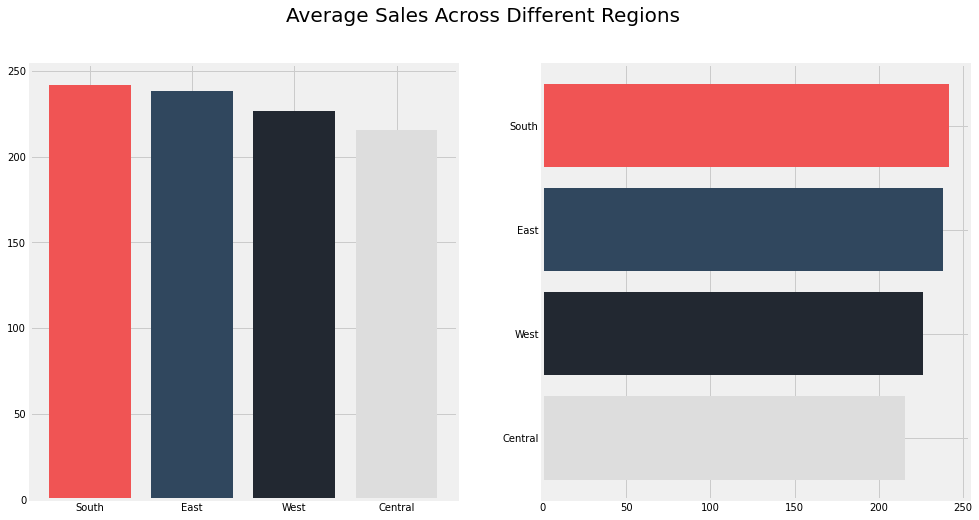

In [4]:
# First of all, we are going to take only the subset of data for our purpose. (To keep things simple)
df_bar = df[['Region','Sales']]

# Grouping the DataFrame based on Regions and taking mean of profit across each of them.
# The reason for sorting is to show the larger values at the beginning (Best Practice)
df_bar = df_bar.groupby('Region').mean().sort_values(by='Sales', ascending=False)

plt.figure(figsize=[15,8]) # Setting the figure size

# Visualizing using Bar Chart
plt.suptitle("Average Sales Across Different Regions", size=20)

# Plotting the BarChart
plt.subplot(1,2,1)
plt.bar(x=df_bar.index, height='Sales', color=['#F05454','#30475E','#222831','#DDDDDD'], data=df_bar)

# Plotting the Horizontal BarChart (Use this if there are many unique values for a Categorical Feature)
plt.subplot(1,2,2)
plt.barh(y=df_bar.index, width='Sales', color=['#F05454','#30475E','#222831','#DDDDDD'], data=df_bar)
plt.gca().invert_yaxis() # Inverting the Y Axis

plt.show()

<p style="font-size:120%">📌It is always better to display the values in the BarChart in an order<strong>(Prefrably Highest to Lowest)</strong>.</p> 

<p style="font-size:120%">📌You can further improve this plot by <strong>adding annotations</strong> for each of the bar. Basically what I mean by that is, to show "Sales" values on top of each Bar.</p>

<i style="font-size:120%">📌<strong><mark>Both the Bar Charts convey the same insights. A horizontal BarChart is preferred when the number of unique values in the Categorical Feature is more.</mark></strong></i>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>To Check</strong> <strong style="color:black">Trend Over Period Of Time:</strong></h1>

<p style="font-size:120%"><strong>Consider The Following Business Problem Statement: </strong>Your Stakeholders would like to understand the trend for Average Profit and Sales across all these years.</p>

<p style="font-size:120%">In this case, <strong>the Profit and Sales are your Numerical features</strong> and your <strong>Order Date is your Date/Time Periods Feature.</strong> Therefore, <strong><mark>a Line Chart is the best visualization to convey your insights!</mark></strong> This is because, with Line Charts, you can <strong><mark>show trend of both Sales and Profit over the Time Period.</mark></strong></p>

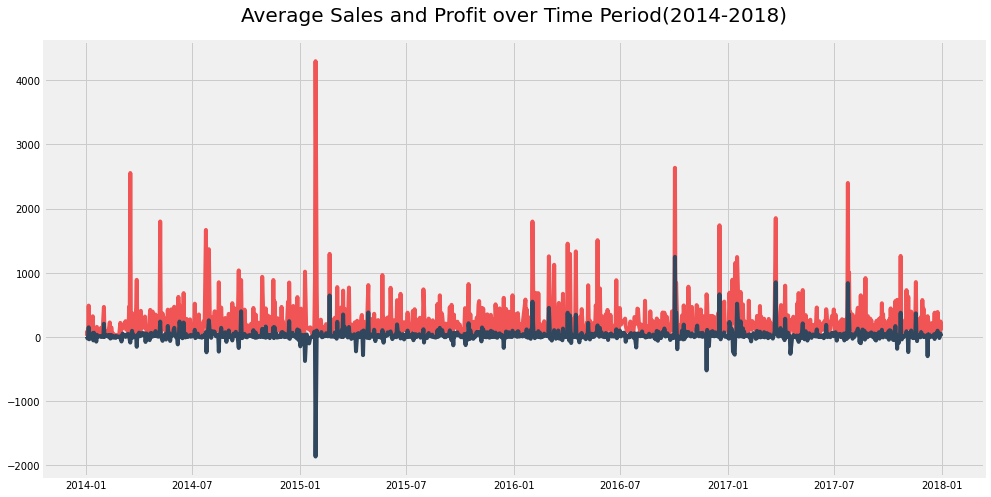

In [5]:
# First of all, we are going to take only the subset of data for our purpose. (To keep things simple)
df_line = df[['Order Date','Sales','Profit']].sort_values('Order Date') # Chronological Ordering
df_line['Order Date'] = pd.to_datetime(df_line['Order Date']) # Converting into DateTime
df_line = df_line.groupby('Order Date').mean() # Groupby to get the average Sales and Profit on each day

# Visualizing the Line Chart
plt.figure(figsize=[15,8])
plt.plot(df_line.index, 'Sales', data=df_line, color='#F05454') # Avg Sales over Time
plt.plot(df_line.index, 'Profit', data=df_line, color='#30475E') # Avg Profit over Time
plt.title("Average Sales and Profit over Time Period(2014-2018)", size=20, pad=20)

plt.show()

<p style="font-size:120%">📌It is always better to display the values in the LineChart in a <strong>Chronological Order</strong>.</p> 

<p style="font-size:120%">📌You can further improve this plot by <strong>adding annotations</strong> for certain event in the timeline to catch the reader's attention.</p>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>To Check</strong> <strong style="color:black">Distribution:</strong></h1>

<p style="font-size:120%"><strong>Consider The Following Business Problem Statement: </strong>Your Stakeholders would like to understand the distribution of Profit and Sales. Additionally, they would also want to know if there are any potential outliers that can impact their decision making.</p>

<p style="font-size:120%">In this case, <strong>the Profit and Sales are your Numerical features</strong>. Therefore, <strong><mark>a Histogram is the best visualization when it comes to understanding the distribution and Boxplots are great to look for potential outliers!</mark></strong> Additionally, we can also throw in <strong>a KDE plot to understand the density distribution.</strong></p>

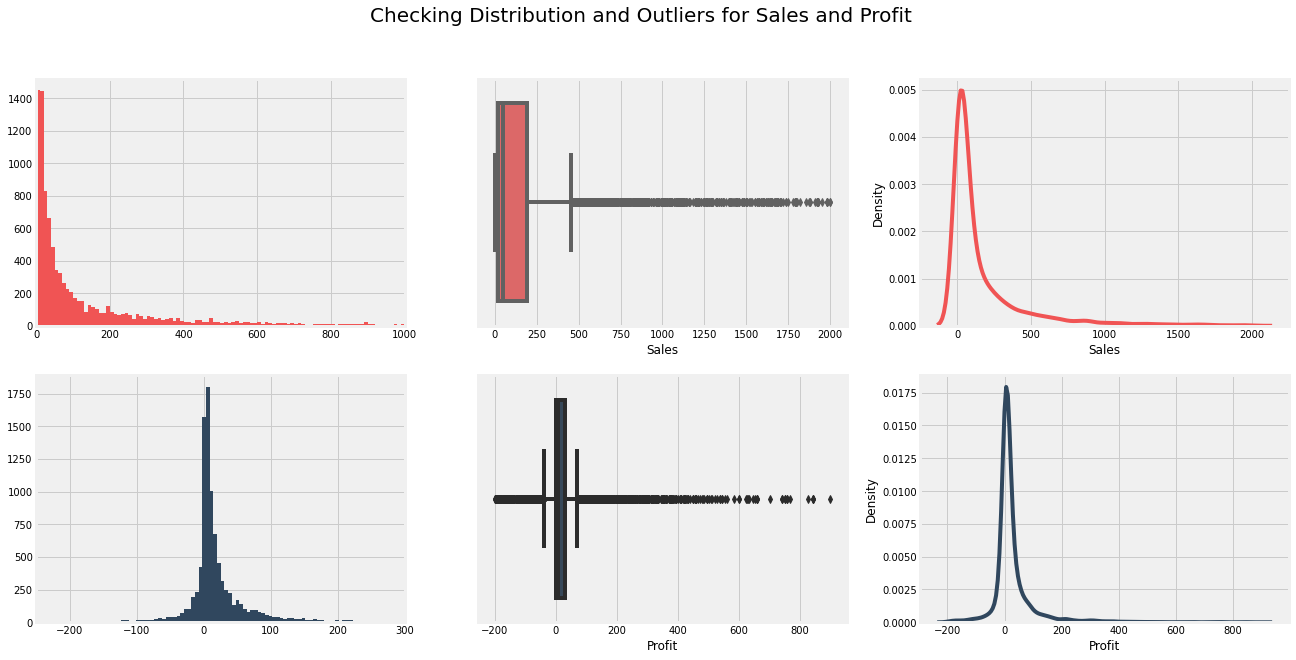

In [6]:
# First of all, we are going to take only the subset of data for our purpose. (To keep things simple)
df_dist = df[['Sales','Profit']]

################################################################
# Fixing the Outliers (It is okay if you do not understand this)
'''I am doing this so that we can see the visuals better. Do not
do this randomly'''

df_dist = df_dist[df_dist['Sales'] <= 2000]
df_dist = df_dist[df_dist['Profit'] <= 2000]
df_dist = df_dist[df_dist['Profit'] >= -200]

################################################################

# Visualizing the histograms
plt.figure(figsize=[20,10])

plt.suptitle("Checking Distribution and Outliers for Sales and Profit", size=20)

# Histogram for Sales
plt.subplot(2,3,1)
plt.hist(df_dist['Sales'], bins=200, color='#F05454')
plt.xlim(0,1000)

# Boxplot of  for Sales
plt.subplot(2,3,2)
sns.boxplot(df_dist['Sales'], color='#F05454')

# KDEPlot for Sales
plt.subplot(2,3,3)
sns.kdeplot(x=df_dist['Sales'], color='#F05454')

################################################################
# Histogram for Profit
plt.subplot(2,3,4)
plt.hist(df_dist['Profit'], bins=200, color='#30475E')
plt.xlim(-250,300)

# Boxplot of  for Profit
plt.subplot(2,3,5)
sns.boxplot(df_dist['Profit'], color='#30475E')

# KDEPlot for Sales
plt.subplot(2,3,6)
sns.kdeplot(x=df_dist['Profit'], color='#30475E')

plt.show()

<p style="font-size:120%">📌From the visualizations above, you can clearly show your team/client/stakeholders <strong><mark>the Distribution using Histogram, the Outliers using Boxplot and Finally the Desity distribution using KDE Plot.</mark></strong></p> 

<p style="font-size:120%">📌From here, you can make the necessary business decisions after taking into considerations the different outliers that govern your decision.</p>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>Relationship</strong> <strong style="color:black">Between Numerical Columns:</strong></h1>

<p style="font-size:120%"><strong>Consider The Following Business Problem Statement: </strong>Your Stakeholders would like to understand how the Sales impact Profit for different Customer Segments.</p>

<p style="font-size:120%">In this case, <strong>the Profit and Sales are your Numerical features</strong>. Therefore to check the relationship between them, <strong><mark>a Scatterplot is the best visualization!</mark></strong></p>

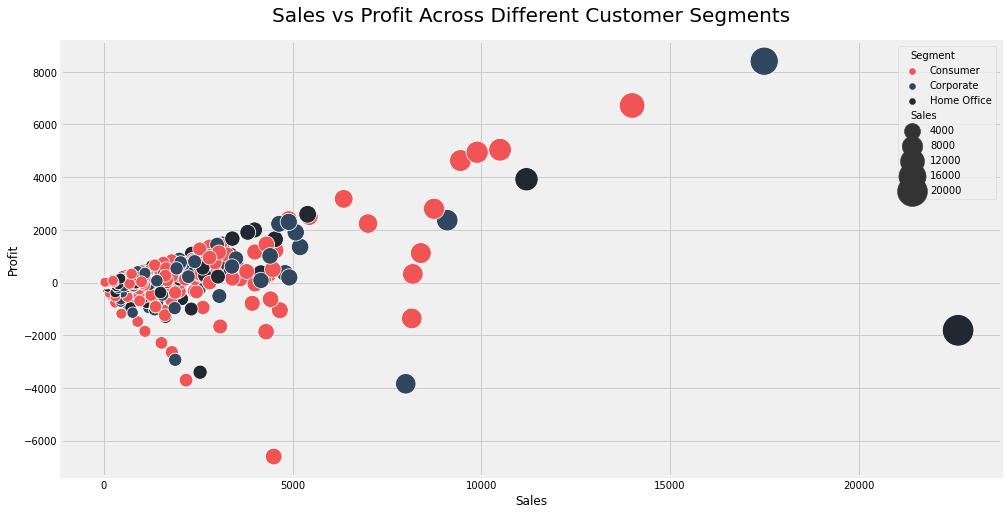

In [7]:
# Again taking a subset of data (To keep things simple)
df_scatter = df[['Sales','Profit','Segment']]

# Visualizing the ScatterPlot
plt.figure(figsize=[15,8])
# Profit in the Y axis, and Sales in the X. Hue will classify the dots according to Segment.
# The size of the dots are according to the volumen of "Sales".
sns.scatterplot(x=df_scatter['Sales'], y=df_scatter['Profit'], hue=df_scatter['Segment'], palette=['#F05454','#30475E','#222831'], size=df_scatter["Sales"], sizes=(100,1000), legend='auto') 
plt.title("Sales vs Profit Across Different Customer Segments", size=20, pad=20)
plt.show()

<p style="font-size:120%">📌The ScatterPlot probably has <strong><mark>the maximum number of parameters among all the other visualizations out there.</mark></strong></p> 

<i style="font-size:120%">📌<strong><mark>ScatterPlots are a great way to visualize correlation between different features.</mark></strong></i>

<p style="font-size:120%">📌It is a great way to visualize the relationship between features. Please explore this visualization more to extract even more insights from it!</p>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>Composition</strong> <strong style="color:black">Of Features:</strong></h1>

<p style="font-size:120%"><strong>Consider The Following Business Problem Statement: </strong>Your Stakeholders would like to understand how Shipping Mode has an impact on the Sum of Profit and Sales. They would also like to see the composition of Categories for both Sales and Profit.</p>

<p style="font-size:120%">In this case, <strong>the Profit and Sales are your Numerical features</strong> and the <strong>Shipping Mode and Category are Categorical in Nature</strong>. Therefore to check the relationship between them, <strong><mark>we will build a Stacked BarChart along with a PieChart for composition of Category!</mark></strong></p>

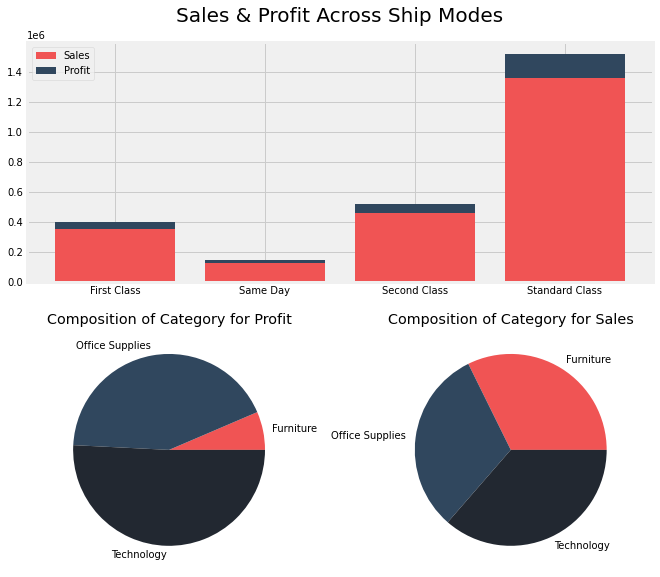

In [8]:
# Taking a subset of data (To keep things simple)
df_stackb = df[['Ship Mode','Sales','Profit']]
# taking a groupby on category and then ship mode...
df_stackb = df_stackb.groupby(['Ship Mode']).sum().reset_index()

# Visualizing the Stacked BarChart
plt.figure(figsize=[10,15])
plt.subplot(3,1,1)
plt.bar(x=df_stackb['Ship Mode'], height=df_stackb['Sales'], color='#F05454')
plt.bar(x=df_stackb['Ship Mode'], height=df_stackb['Profit'], bottom=df_stackb['Sales'], color='#30475E')
plt.title("Sales & Profit Across Ship Modes", size=20, pad=20)
plt.legend(['Sales','Profit'])

###################################################################
# Taking a subset of data (To keep things simple)
df_pie = df[['Category','Sales','Profit']]
# taking a groupby on category and then ship mode...
df_pie = df_pie.groupby(['Category']).sum().reset_index()

# Visualizing the Pie Chart (Profit)
plt.subplot(3,2,3)
plt.pie(df_pie['Profit'], labels=df_pie['Category'], colors=['#F05454','#30475E','#222831','#DDDDDD'])
plt.title("Composition of Category for Profit")

# Visualizing the Pie Chart (Sales)
plt.subplot(3,2,4)
plt.pie(df_pie['Sales'], labels=df_pie['Category'], colors=['#F05454','#30475E','#222831','#DDDDDD'])
plt.title("Composition of Category for Sales")

plt.show()

<p style="font-size:120%">📌Using The Stacked BarChart to show composition <strong><mark>for mutiple features is sometimes called Bi-Variate or Multi-Variate Analysis.</mark></strong></p> 

<i style="font-size:120%">📌<strong><mark>Avoid Pie Charts as much as possible most of the times. Better to perform Multi-variate analysis using other Visualizations.</mark></strong></i>

<p style="font-size:120%">📌Keep your color codings consitant across visualizations to avoid any confusion!</p>

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong><strong style="color:black">[BONUS]</strong>Composition</strong> <strong style="color:black">Using TreeMap:</strong></h1>

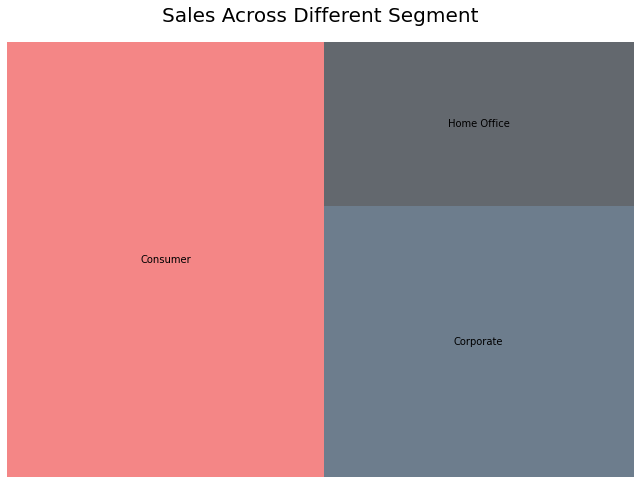

In [9]:
###################################################################
# BONUS SECTION (TreeMap Creation) (https://jingwen-z.github.io/data-viz-with-matplotlib-series5-treemap/)
###################################################################
# Taking a subset of data (To keep things simple)
df_tree = df[['Segment','Sales']]
# taking a groupby on category and then ship mode...
df_tree = df_tree.groupby(['Segment']).sum().reset_index()

# Visualizing the TreeMap (Sales)
plt.figure(figsize=[10,8])

squarify.plot(sizes=df_tree['Sales'], label=df_tree['Segment'],
              color=['#F05454','#30475E','#222831'], alpha=0.7)
plt.title("Sales Across Different Segment", size=20, pad=20)
plt.axis('off')

plt.show()

<h1 style="font-size:50px;color:#F05454;text-align:left"><strong>The Cheat</strong> <strong style="color:black">Sheet:</strong></h1>

<p style="font-size:120%">The below cheatsheet can be used as a reference to keep in mind what visualizations we can use.</p> 

<img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F1688884%2Fb4372f0e806b6f75c7b56904b1159a68%2FData%20Visualization%20Cheatsheet.jpg?generation=1592767560257939&alt=media">Picture Credits <a href="https://www.kaggle.com/getting-started/160583" style="text-decoration:none">Mohammad Essam</a></img>

<h3 style="font-size:30px;color:#F05454;text-align:center">Leave an upvote👍 if you learnt something new here...</h3>